##### IMPORTS & MODULES

In [75]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from data_utils import ISICDataset

##### Initializing Paths, and DataSets

In [76]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")

# Directories
DATA_DIR = "./Data"
IMG_DIR = os.path.join(DATA_DIR, "ISBI2016_ISIC_Part1_Training_Data")
MASK_DIR = os.path.join(DATA_DIR, "ISBI2016_ISIC_Part1_Training_GroundTruth")

# Initialize the Dataset
DATASET = ISICDataset(IMG_DIR, MASK_DIR)

# Split into Train (80%) and Validation (20%)
train_size = int(0.8 * len(DATASET))
val_size = len(DATASET) - train_size

train_dataset, val_dataset = random_split(DATASET, [train_size, val_size])
print(f"Training Data SIZE   : {len(train_dataset)}")
print(f"Validation Data SIZE : {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

Using Device: cuda
Training Data SIZE   : 720
Validation Data SIZE : 180


##### Segmentation Metrics

In [77]:
# Defining Dice loss, Dice score, and IoU score

# import torch


def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)  # flattens (8, 1, 256, 256) → (N,)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return 1 - (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def dice_score(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    return (2.0 * intersection + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + smooth) / (union + smooth)

## ----------------------------------------------------

# U-Net Architecture


In [78]:
# Defining the Architecture

# import torch.nn as nn


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.d1 = DoubleConv(3, 64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.u3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.c3 = DoubleConv(512, 256)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.c2 = DoubleConv(256, 128)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.c1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2))

        b = self.bottleneck(self.p3(d3))

        u3 = self.u3(b)
        u3 = torch.cat([u3, d3], dim=1)
        u3 = self.c3(u3)

        u2 = self.u2(u3)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.c2(u2)

        u1 = self.u1(u2)
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.c1(u1)

        return self.out(u1)  # logits output

##### Initializing model, optimizer, loss function, and scheduler

In [ ]:
# import torch.optim as optim

model = UNet().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
bce = nn.BCEWithLogitsLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5
)

##### Training loop with validation, metrics, and model checkpointing

In [ ]:

# Creating a Folder to store the best_model.pth
os.makedirs("models", exist_ok = True)

epochs = 50
best_dice = 0

for epoch in range(epochs):
    # ---- TRAIN ----
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        loss = bce(preds, masks) + dice_loss(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    total_dice = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)

            loss = bce(preds, masks) + dice_loss(preds, masks)
            val_loss += loss.item()

            total_dice += dice_score(preds, masks).item()
            total_iou += iou_score(preds, masks).item()

    avg_dice = total_dice / len(val_loader)

    # Scheduler step
    scheduler.step(avg_dice)

    # Save best model
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "models/best_model.pth")

    print(f"""
Epoch {epoch + 1}/{epochs}
Train Loss: {train_loss / len(train_loader):.4f}
Val Loss  : {val_loss / len(val_loader):.4f}
Dice Score: {avg_dice:.4f}
IoU Score : {total_iou / len(val_loader):.4f}
""")


Epoch 1/50
Train Loss: 1.1837
Val Loss  : 0.9445
Dice Score: 0.6837
IoU Score : 0.5281


Epoch 2/50
Train Loss: 0.8745
Val Loss  : 0.6595
Dice Score: 0.7596
IoU Score : 0.6180


Epoch 3/50
Train Loss: 0.7730
Val Loss  : 0.6156
Dice Score: 0.7663
IoU Score : 0.6279


Epoch 4/50
Train Loss: 0.7348
Val Loss  : 0.6785
Dice Score: 0.7409
IoU Score : 0.5943


Epoch 5/50
Train Loss: 0.7319
Val Loss  : 0.6290
Dice Score: 0.7785
IoU Score : 0.6432


Epoch 6/50
Train Loss: 0.6481
Val Loss  : 0.5769
Dice Score: 0.7936
IoU Score : 0.6634


Epoch 7/50
Train Loss: 0.5830
Val Loss  : 0.5642
Dice Score: 0.7941
IoU Score : 0.6633


Epoch 8/50
Train Loss: 0.5520
Val Loss  : 0.4473
Dice Score: 0.8287
IoU Score : 0.7111


Epoch 9/50
Train Loss: 0.4938
Val Loss  : 0.4293
Dice Score: 0.8343
IoU Score : 0.7193


Epoch 10/50
Train Loss: 0.4580
Val Loss  : 0.4601
Dice Score: 0.8288
IoU Score : 0.7112


Epoch 11/50
Train Loss: 0.4969
Val Loss  : 0.4136
Dice Score: 0.8433
IoU Score : 0.7319


Epoch 12/50
Train 


##### Loading the best saved model

In [ ]:

model.load_state_dict(torch.load("models/best_model.pth"))
model.eval()

C:\Users\Harish\AppData\Local\Temp\ipykernel_17080\3042060505.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/best_model.pth"))


UNet(
  (d1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p3): MaxPool2d(


##### Visualizing Predictions vs Ground Truth for "U-Net Architecture"

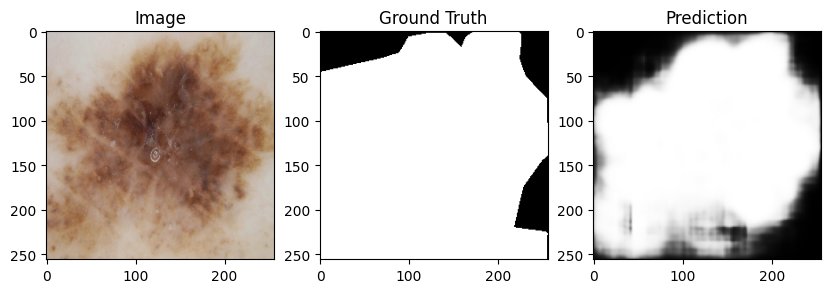

In [94]:
# import matplotlib.pyplot as plt

images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    preds = model(images)
    preds = torch.sigmoid(preds)

preds = preds.cpu().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.title("Image")
plt.imshow(images[0].cpu().permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(masks[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(preds[0].squeeze(), cmap='gray')

plt.show()

## ----------------------------------------------------

# Attention U-Net Architecture

This section implements the Attention U-Net architecture, which integrates attention gates into the standard U-Net to improve segmentation performance by focusing on relevant features while suppressing noise

In [98]:
# import torch.nn as nn
# import torch

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Contracting Path
        self.d1 = DoubleConv(3, 64)
        self.p1 = nn.MaxPool2d(2)

        self.d2 = DoubleConv(64, 128)
        self.p2 = nn.MaxPool2d(2)

        self.d3 = DoubleConv(128, 256)
        self.p3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        # Expanding Path with Attention Gates
        self.u3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.att3 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.c3 = DoubleConv(512, 256) # 256 (from ConvTranspose) + 256 (from skip connection with attention)

        self.u2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.att2 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.c2 = DoubleConv(256, 128) # 128 (from ConvTranspose) + 128 (from skip connection with attention)

        self.u1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.c1 = DoubleConv(128, 64) # 64 (from ConvTranspose) + 64 (from skip connection with attention)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        # Contracting Path
        d1 = self.d1(x) # 64
        p1 = self.p1(d1)

        d2 = self.d2(p1) # 128
        p2 = self.p2(d2)

        d3 = self.d3(p2) # 256
        p3 = self.p3(d3)

        b = self.bottleneck(p3) # 512

        # Expanding Path
        u3 = self.u3(b)
        gating_signal3 = u3 # Gating signal is the upsampled output from the previous layer
        x_skip3 = self.att3(gating_signal3, d3) # Apply attention to the skip connection
        u3 = torch.cat([u3, x_skip3], dim=1)
        u3 = self.c3(u3)

        u2 = self.u2(u3)
        gating_signal2 = u2
        x_skip2 = self.att2(gating_signal2, d2)
        u2 = torch.cat([u2, x_skip2], dim=1)
        u2 = self.c2(u2)

        u1 = self.u1(u2)
        gating_signal1 = u1
        x_skip1 = self.att1(gating_signal1, d1)
        u1 = torch.cat([u1, x_skip1], dim=1)
        u1 = self.c1(u1)

        return self.out(u1)

##### Initializing model, optimizer, loss function, and scheduler

In [99]:
# import torch.optim as optim

attention_model = AttentionUNet().to(device)

attention_optimizer = optim.Adam(attention_model.parameters(), lr=1e-4)
bce_loss = nn.BCEWithLogitsLoss() # Reuse existing BCEWithLogitsLoss

attention_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    attention_optimizer, mode='max', patience=3, factor=0.5
)

##### Training loop with validation, metrics, and model checkpointing

In [100]:
epochs_attn = 50
best_dice_attn = 0

for epoch in range(epochs_attn):

    # ---- TRAIN ----
    attention_model.train()
    train_loss_attn = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = attention_model(images)

        loss = bce_loss(preds, masks) + dice_loss(preds, masks) # Reuse existing dice_loss

        attention_optimizer.zero_grad()
        loss.backward()
        attention_optimizer.step()

        train_loss_attn += loss.item()

    # ---- VALIDATION ----
    attention_model.eval()
    val_loss_attn = 0
    total_dice_attn = 0
    total_iou_attn = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = attention_model(images)

            loss = bce_loss(preds, masks) + dice_loss(preds, masks)
            val_loss_attn += loss.item()

            total_dice_attn += dice_score(preds, masks).item() # Reuse existing dice_score
            total_iou_attn += iou_score(preds, masks).item()   # Reuse existing iou_score

    avg_dice_attn = total_dice_attn / len(val_loader)

    # Scheduler step
    attention_scheduler.step(avg_dice_attn)

    # Save best model
    if avg_dice_attn > best_dice_attn:
        best_dice_attn = avg_dice_attn
        torch.save(attention_model.state_dict(), "models/best_attention_model.pth") 
        # We have already created the models folder in the above run..

    print(f"""
Epoch {epoch+1}/{epochs_attn}
Train Loss (Attn): {train_loss_attn/len(train_loader):.4f}
Val Loss (Attn)  : {val_loss_attn/len(val_loader):.4f}
Dice Score (Attn): {avg_dice_attn:.4f}
IoU Score (Attn) : {total_iou_attn/len(val_loader):.4f}
""")


Epoch 1/50
Train Loss (Attn): 1.1233
Val Loss (Attn)  : 1.0873
Dice Score (Attn): 0.5225
IoU Score (Attn) : 0.3623


Epoch 2/50
Train Loss (Attn): 0.7297
Val Loss (Attn)  : 2.4454
Dice Score (Attn): 0.0014
IoU Score (Attn) : 0.0007


Epoch 3/50
Train Loss (Attn): 0.6143
Val Loss (Attn)  : 1.1758
Dice Score (Attn): 0.4943
IoU Score (Attn) : 0.3334


Epoch 4/50
Train Loss (Attn): 0.5487
Val Loss (Attn)  : 0.5968
Dice Score (Attn): 0.7652
IoU Score (Attn) : 0.6237


Epoch 5/50
Train Loss (Attn): 0.5277
Val Loss (Attn)  : 0.6515
Dice Score (Attn): 0.7615
IoU Score (Attn) : 0.6222


Epoch 6/50
Train Loss (Attn): 0.5070
Val Loss (Attn)  : 1.1941
Dice Score (Attn): 0.5929
IoU Score (Attn) : 0.4277


Epoch 7/50
Train Loss (Attn): 0.4920
Val Loss (Attn)  : 0.6761
Dice Score (Attn): 0.7506
IoU Score (Attn) : 0.6066


Epoch 8/50
Train Loss (Attn): 0.4730
Val Loss (Attn)  : 0.5736
Dice Score (Attn): 0.7887
IoU Score (Attn) : 0.6537


Epoch 9/50
Train Loss (Attn): 0.5063
Val Loss (Attn)  : 0.5602



##### Loading the best saved model

In [103]:
attention_model.load_state_dict(torch.load("models/best_attention_model.pth"))
attention_model.eval()

C:\Users\Harish\AppData\Local\Temp\ipykernel_17080\141472234.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  attention_model.load_state_dict(torch.load("models/best_atte

AttentionUNet(
  (d1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (d3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (p3): M


##### Visualizing Predictions vs Ground Truth for "Attention U-Net Architecture"

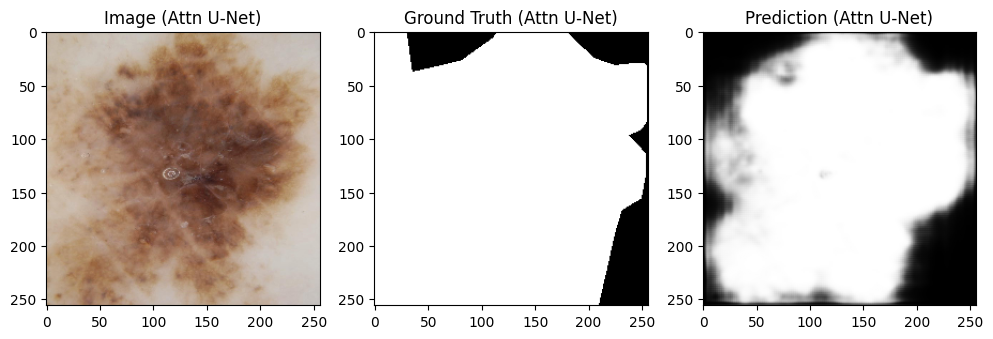

In [104]:
# import matplotlib.pyplot as plt

images_attn, masks_attn = next(iter(val_loader))
images_attn = images_attn.to(device)

with torch.no_grad():
    preds_attn = attention_model(images_attn)
    preds_attn = torch.sigmoid(preds_attn)

preds_attn = preds_attn.cpu().numpy()

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Image (Attn U-Net)")
plt.imshow(images_attn[0].cpu().permute(1,2,0))

plt.subplot(1,3,2)
plt.title("Ground Truth (Attn U-Net)")
plt.imshow(masks_attn[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction (Attn U-Net)")
plt.imshow(preds_attn[0].squeeze(), cmap='gray')

plt.show()

## ----------------------------------------------------